# Importación y descarga de datos

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descarga de datos

tickers = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "USDJPY": "JPY=X",
    "BTC": "BTC-USD",
    "ETH": "ETH-USD"
}

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2018-01-01", progress=False)
    df = df[["Close"]].rename(columns={"Close": name})
    data[name] = df
    print(f"{name}: {len(df)} registros descargados")

EURUSD: 2121 registros descargados
GBPUSD: 2121 registros descargados
USDJPY: 2120 registros descargados
BTC: 2977 registros descargados
ETH: 2977 registros descargados


Vemos diferencias de registros, pero eso viene porque el mercado tradicional opera de lunes a viernes, en cambio,  el mercado de las criptomonedas cotizan los 365 días del año.

# Primera exploración

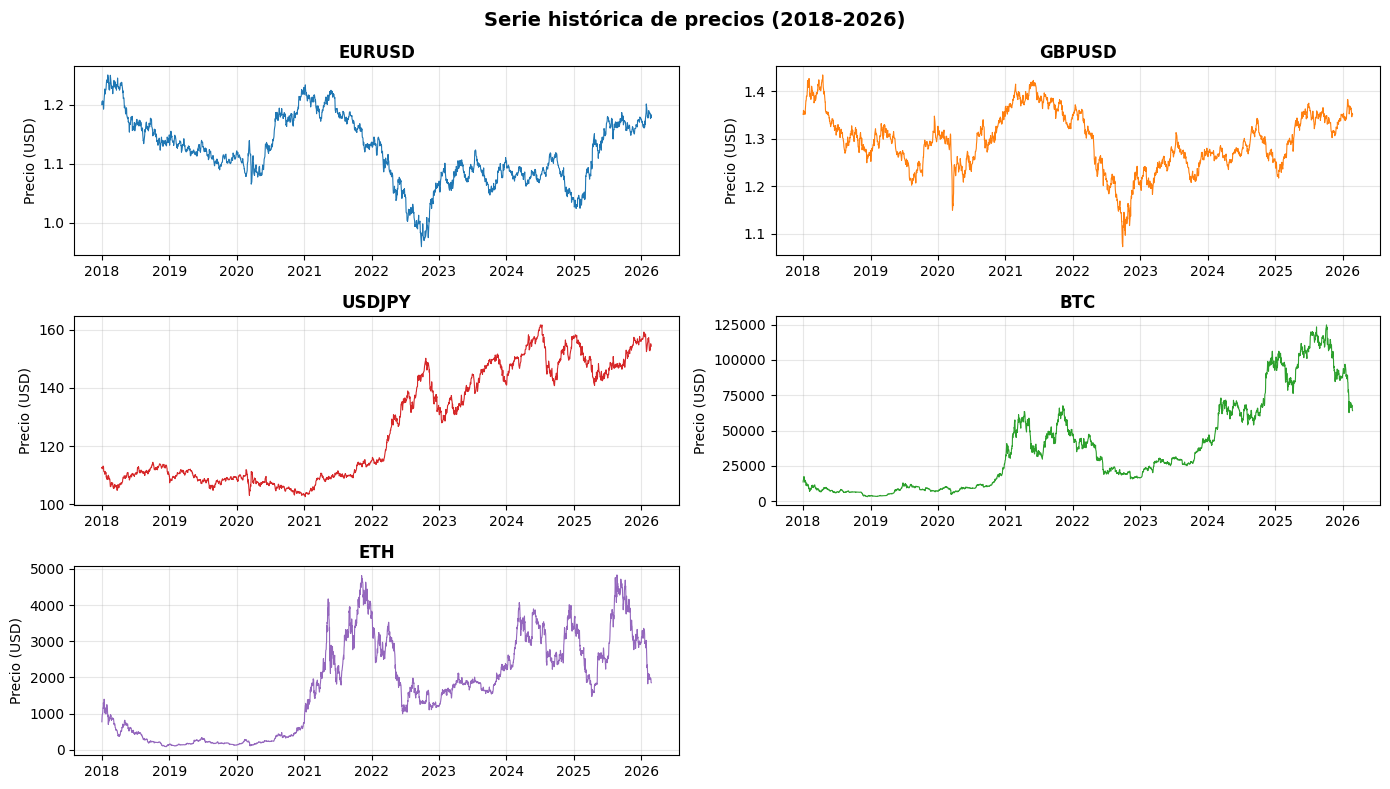

Gráfico guardado en la carpeta results


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle("Serie histórica de precios (2018-2026)", fontsize=14, fontweight="bold")

colores = {"EURUSD": "#1f77b4", "GBPUSD": "#ff7f0e", "USDJPY": "#d62728", "BTC": "#2ca02c", "ETH": "#9467bd"}

for ax, (name,df) in zip (axes.flatten(), data.items()):
    ax.plot(df.index, df[name], color=colores[name], linewidth=0.8)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Precio (USD)")
    ax.grid (True, alpha=0.3)

axes[2, 1].set_visible(False)
plt.tight_layout()
plt.savefig("../results/01_series_historicas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

- A simple vista podemos observar que las divisas EUR/USD oscila entre 0.95 y 1.25, el GBP/USD entre 1.10 y 1.45. No tienen tendencia a largo plazo y tampoco tienen una amplitud ancha.

- El YEN entre el 2018 y 2021 se mantuvo estable entre 105 y 115 yenes por dólar americano, la causa puede derivar de política expansiva del Banco de Japón en esa época mantuvo los tipos de interés negativos o cero durante bastantes años. De cara al 2022, el valor del Yen se deprecia hasta llegar a los 150 yenes por cada dólar americano. La causa de esta depreciación puede ser porque la Reserva Federal americana subió los tipos de interés en esa época, pero Banco de Japón mantuvo los tipos a cero, eso generó la venta de yenes masivamente para comprar dólares. Entre 2023 -2024 el BOJ abandona la política de los tipos de interés a cero teniendo una recuperación.

- En cambio las criptomonedas, BTC pasó de 0 a 120.000$ con caidas de 70-80%. ETH tiene un patrón muy parecido al Bitcoin.

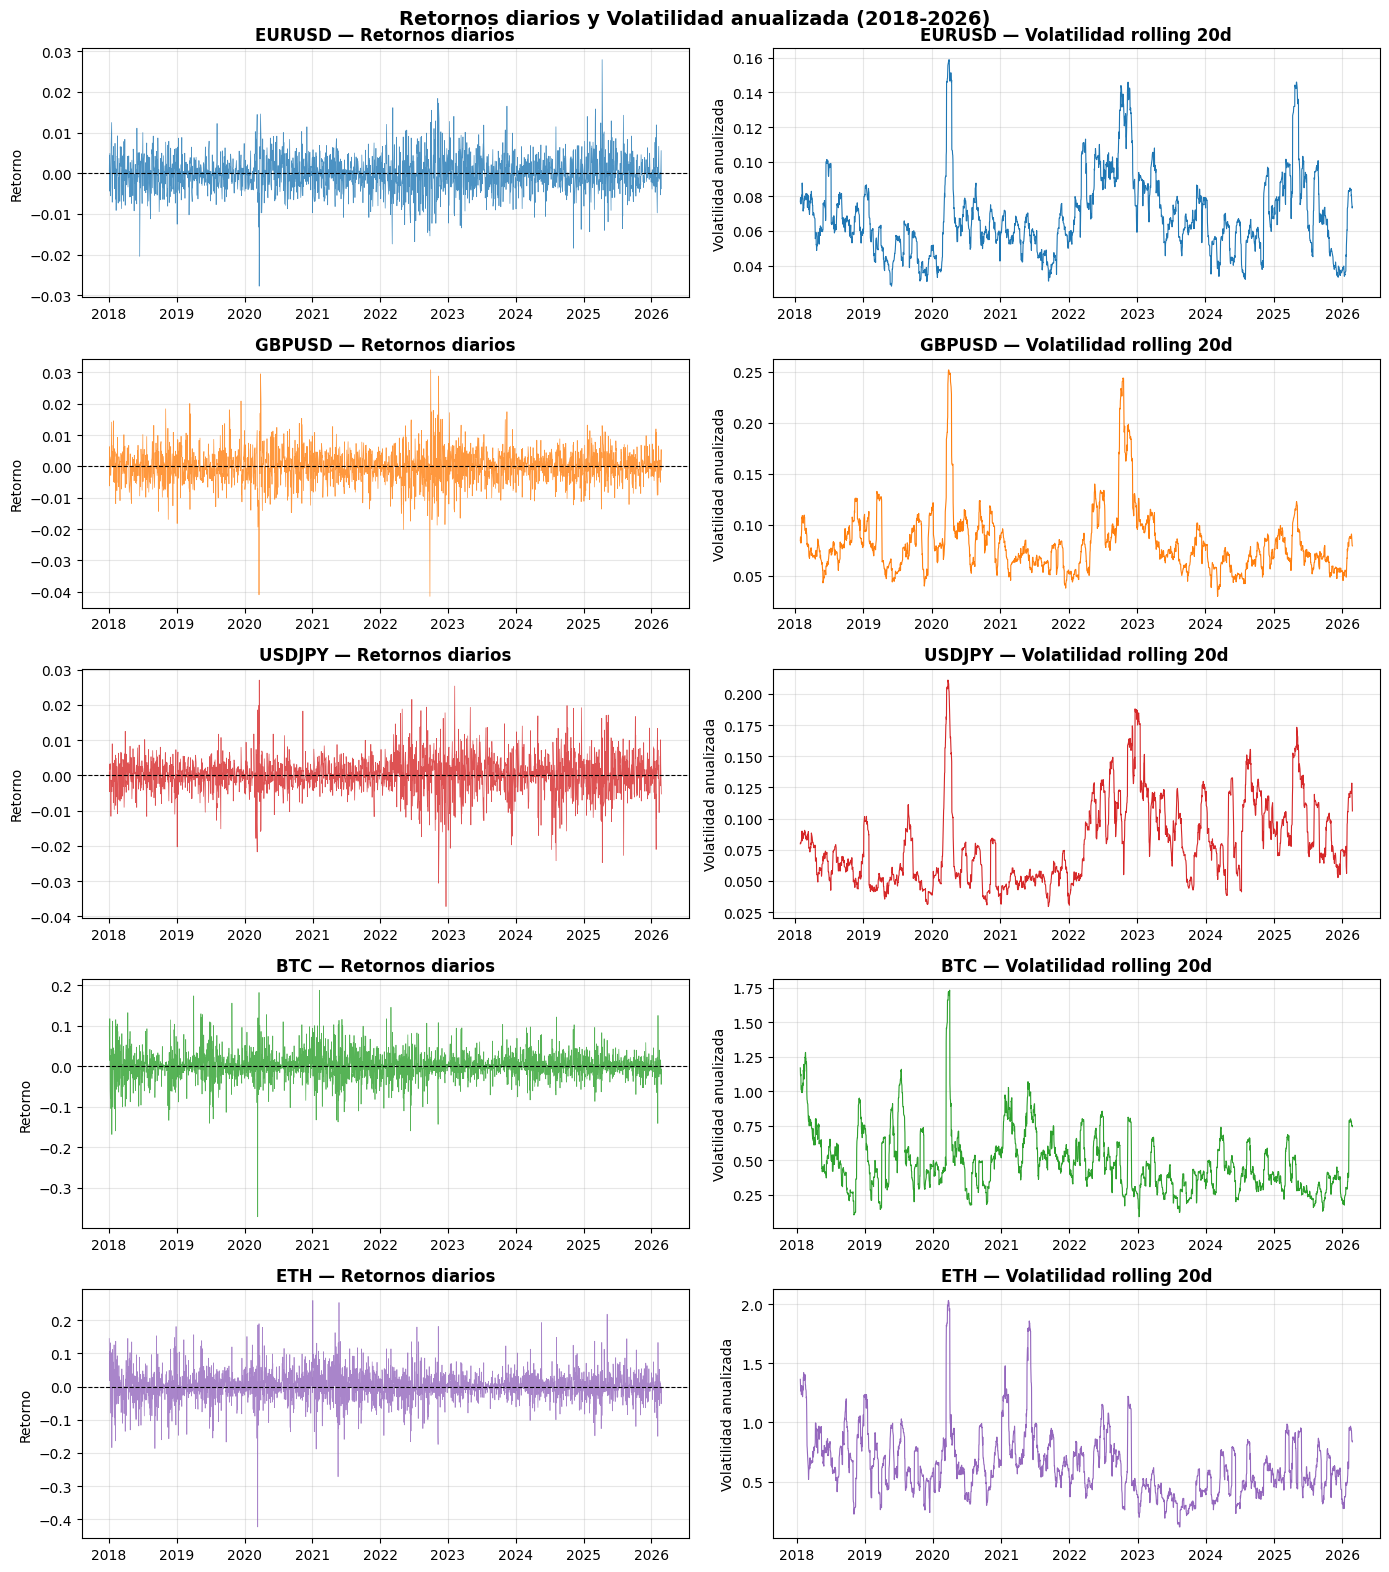

Gráfico guardado en la carpeta results


In [13]:
# Calcular retornos logarítmicos y volatilidad rolling
retornos = {}
volatilidad = {}

for name, df in data.items():
    # Retornos logarítmicos diarios
    ret = df[name].pct_change().dropna()
    retornos[name] = ret
    
    # Volatilidad rolling de 20 días (media móvil de la desviación estándar)
    vol = ret.rolling(window=20).std() * (252 ** 0.5) # Anualizada
    volatilidad[name] = vol
    
# Visualizar retornos y volatilidad
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
fig.suptitle("Retornos diarios y Volatilidad anualizada (2018-2026)", fontsize=14, fontweight="bold")

for i, name in enumerate(data.keys()):
    color = colores[name]
    
    # Retornos
    axes[i, 0].plot(retornos[name].index, retornos[name], color=color, linewidth=0.5, alpha=0.8)
    axes[i, 0].set_title(f"{name} — Retornos diarios", fontweight="bold")
    axes[i, 0].set_ylabel("Retorno")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    
    # Volatilidad
    axes[i, 1].plot(volatilidad[name].index, volatilidad[name], color=color, linewidth=0.8)
    axes[i, 1].set_title(f"{name} — Volatilidad rolling 20d", fontweight="bold")
    axes[i, 1].set_ylabel("Volatilidad anualizada")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/02_retornos_volatilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

* En divisas EUR/USD y GBP/USD: Los retornos se mueven en un del 3% y la volatilidad anualizada entre un 5-15%. Se ve un pico en 2020 debido a la pandemia del COVID y otro en 2022-2023 que deriva por la crisis energética y la guerra de Ucrania,  y pero se acaba estabilizando debido a que son mercados regulados y maduros.

* En el JPY/USD: Se pueden distinguir tres regímenes. Del 2018 a 2021 la volatilidad es baja y estable (5-7%) con retornos diarios casi planos, ahi se vuelve a apreciar el control del Banco de Japón con los tipos de interés negativos. En 2022-23 se produce una explosión de volatilidad hasta llegar al 20%, provocada por la divergencia entre el Fed y el Boj, eso fue la causa de la depreciación del Yen con respecto al dólar. Desde el 2024 la volatilidad disminuye quedándose en torno al 8-12%.

* En las criptomonedas BTC y ETH: Los retornos llegan hasta 30-40% en un solo día y tiene una volatilidad anualizada entre un 150-200% en los picos. La volatilidad cripto no vuelve a niveles bajos como ocurre en las divisas, el "suelo" de BTC está en torno al 25-30% anualizada.

# Limpieza y almacenamiento

In [14]:
import os

# Guarda cada serie en CSV
os.makedirs("../data", exist_ok=True)

for name, df in data.items():
    filepath = f"../data/{name.lower()}_raw.csv"
    df.to_csv(filepath)
    print(f"Guardado: {filepath}")
    
print("\nTodos los datos guardados correctamente en la carpeta data")

Guardado: ../data/eurusd_raw.csv
Guardado: ../data/gbpusd_raw.csv
Guardado: ../data/usdjpy_raw.csv
Guardado: ../data/btc_raw.csv
Guardado: ../data/eth_raw.csv

Todos los datos guardados correctamente en la carpeta data


# Detector de regímenes de volatilidad


In [22]:
regimenes = {}

for name in data.keys():
    vol = volatilidad[name].squeeze().dropna()
    
    # Umbral: percentil 70 de la volatilidad histórica de cada activo
    umbral = vol.quantile(0.70)
    
    # Etiquetar régimen
    regimen = (vol > umbral).astype(int)    # 1 = alta volatilidad, 0 = baja volatilidad
    regimenes[name] = regimen
    
    pct_alta = regimen.mean() * 100
    print(f"Resultados umbrales con su volalitilidad anualizada\n")
    
    print (f"{name}: umbral={umbral:.4f} | Alta vol: {pct_alta:.2f}% del tiempo")

Resultados umbrales con su volalitilidad anualizada

EURUSD: umbral=0.0759 | Alta vol: 29.99% del tiempo
Resultados umbrales con su volalitilidad anualizada

GBPUSD: umbral=0.0877 | Alta vol: 29.99% del tiempo
Resultados umbrales con su volalitilidad anualizada

USDJPY: umbral=0.0945 | Alta vol: 30.00% del tiempo
Resultados umbrales con su volalitilidad anualizada

BTC: umbral=0.5515 | Alta vol: 30.00% del tiempo
Resultados umbrales con su volalitilidad anualizada

ETH: umbral=0.7368 | Alta vol: 30.00% del tiempo


Con los resultados obtenidos, podemos remarcar lo que se veia en las gráficas, si comparamos el BTC con EUR/USD podemos observar que el umbral del Bitcoin es 7 veces mayor que el Euro.

Como utilizamos un percentil del 70 como umbral, por ese motivo vemos que la alta volatilidad ocupa un 30% los días que superan el umbral. El percentil lo escoge quien quiere analizarlo, pero estoy utilizando un estándar habitual, que por lo que he observado en otros papers se suele indicar entre un 70 y un 75%.

El percentil nos sirve para equilibrar y asi poder comparar activos que se mueven distintamente. 



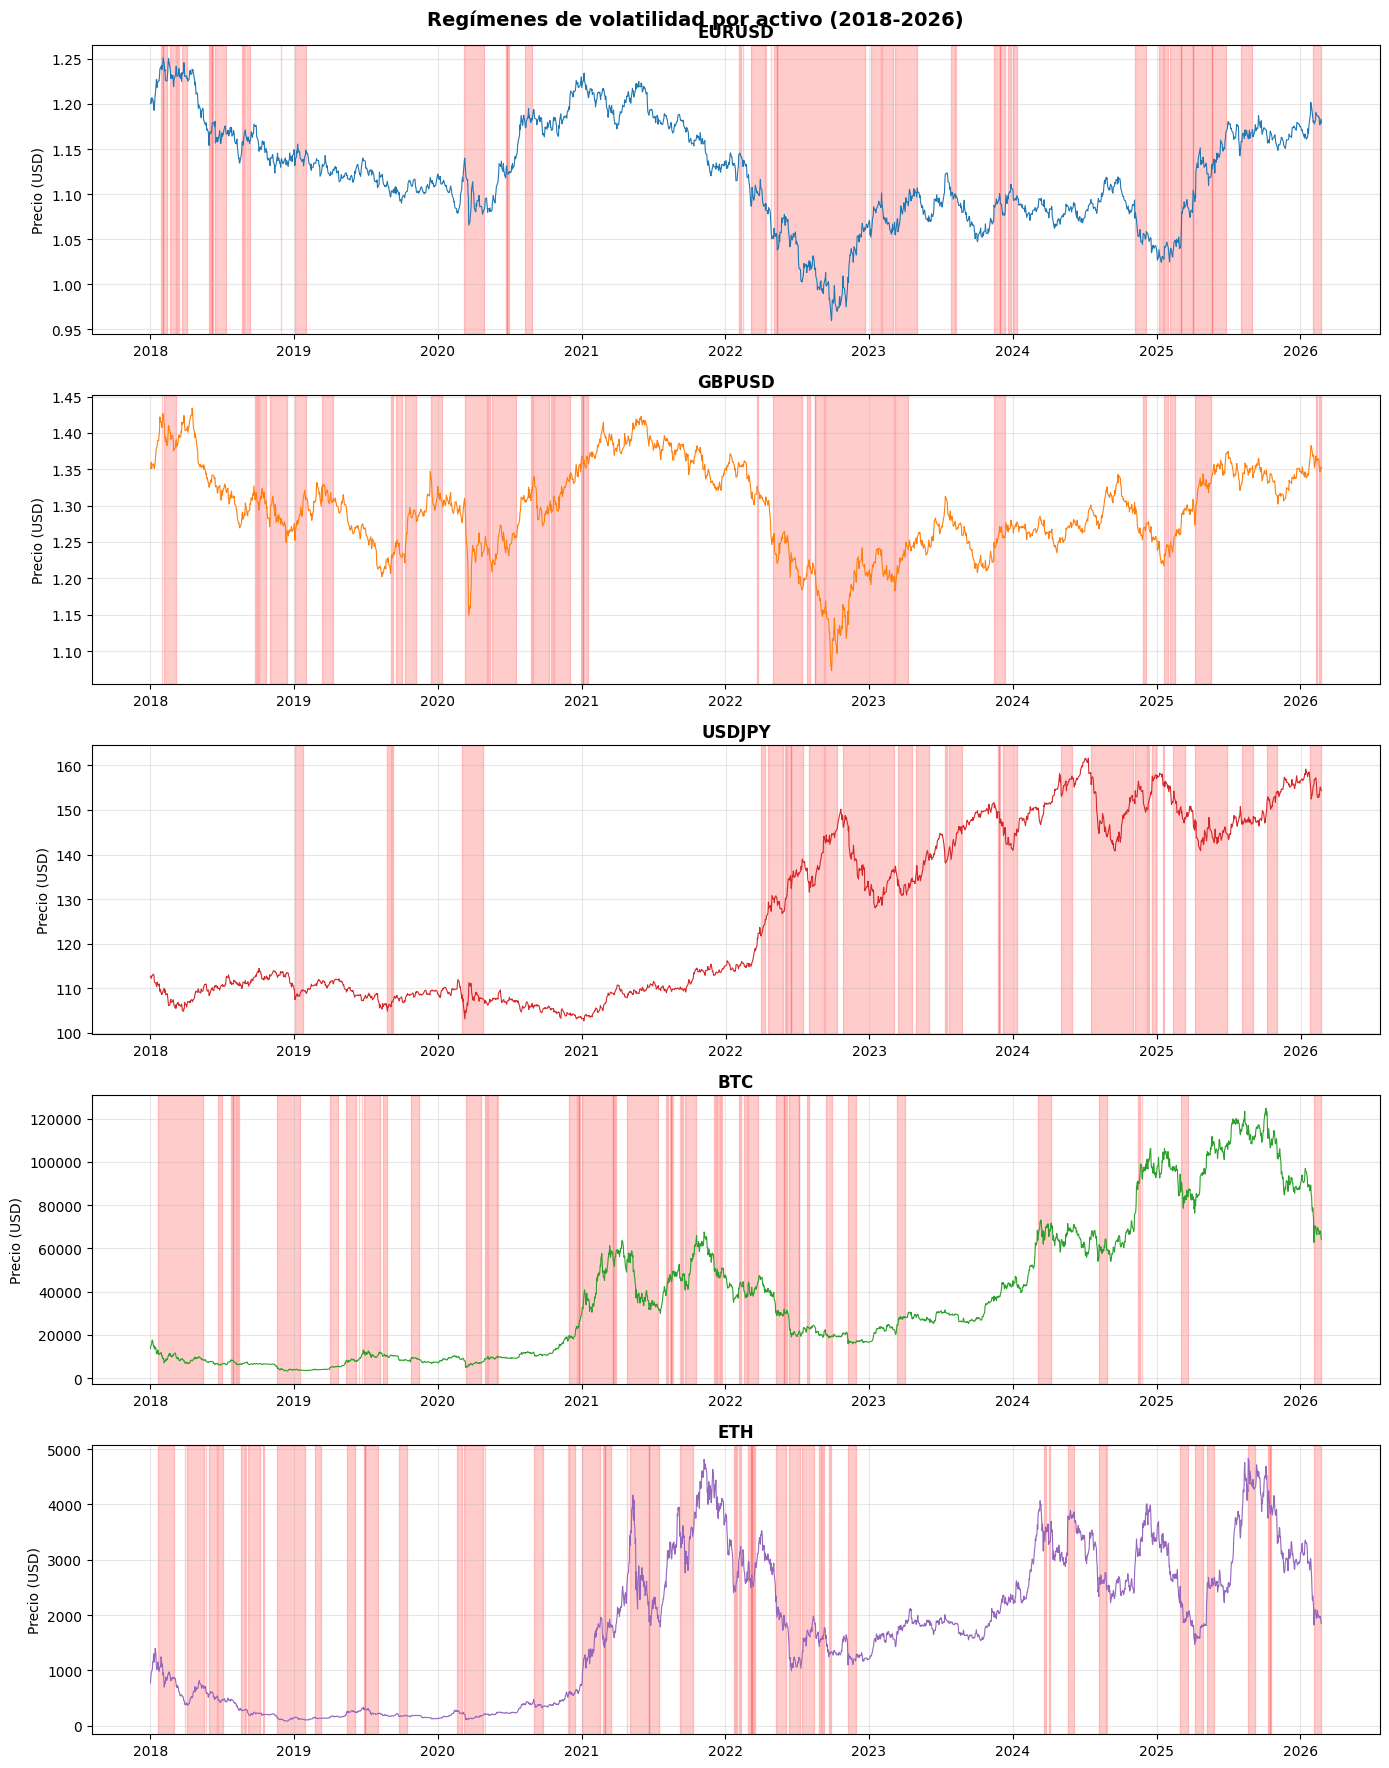

Gráfico guardado en la carpeta resultados


In [23]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle("Regímenes de volatilidad por activo (2018-2026)", fontsize=14, fontweight="bold")

for i, name in enumerate(data.keys()):
    precio = data[name][name]
    regimen = regimenes[name]
    color = colores[name]
    
    axes[i].plot(precio.index, precio, color=color, linewidth=0.8, zorder=2)
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].set_ylabel("Precio (USD)")
    axes[i].grid(True, alpha=0.3)
    
    # Resaltar las zonas de alta volatilidad en rojo
    in_regime = False
    start = None
    for date, val in regimen.items():
        if val == 1 and not in_regime:
            start = date
            in_regime = True
        elif val == 0 and in_regime:
            axes[i].axvspan(start, date, alpha=0.2, color="red", zorder=1)
            in_regime = False
    if in_regime:
        axes[i].axvspan(start, regimen.index[-1], alpha=0.2, color="red", zorder=1)

plt.tight_layout()
plt.savefig("../results/03_regimenes_volatilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta resultados")

Se resaltan las zonas en rojo cuando existen periodos con alta volatilidad sobre el precio real.

En las divisas las zonas rojas son franjas extrechas y dispersas, con periodos cortos de turbulencias que se resuelven rápido. En el EUR/USD hay una zona roja grande y continua entre el 2022-23 (por la crisis energético). En GBP/USD, en cambio, solo hay franjas rojas pequeñas repartidas por toda la serie.

En el USDJPY, entre el 2018 hasta el 2021 casi no tiene zonas rojas y a partir del 2022 se expande el rojo.

En el BTC y ETH las zonas rojas son más frecuentes, especialmente en los periodos 2018, 2021-2022 y 2024-2025. Tiene volatilidad en ambas direcciones, tanto en subidas explosivas como en crashes. 
